In [1]:
import gdown
import arff
import pandas as pd
import os
import scipy.stats as sps
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import roc_auc_score, r2_score
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt

/Users/polushkin-ayu/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
train_url = 'https://drive.google.com/file/d/16NJYjgfQMdXyZomWrbgBM7LT0rvaffoZ/view?usp=sharing'
output_path = "./train.csv.7z"

# gdown.download(train_url, output_path, fuzzy=True, quiet=False)

In [3]:
# !pip3 install py7zr

In [5]:
import py7zr
with py7zr.SevenZipFile(output_path, mode='r') as archive:
    archive.extractall(path=".")

In [6]:
output_path[:-3]

'./train.csv'

In [7]:
df = pd.read_csv(output_path[:-3])

/var/folders/v3/8s1218f95959hxdthxrzj7b80000gn/T/ipykernel_7688/1182222283.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(output_path[:-3])


In [8]:
df.head()

,id,date,store_nbr,item_nbr,unit_sales,onpromotion
0,0,2013-01-01,25,103665,7.0,NaN
1,1,2013-01-01,25,105574,1.0,NaN
2,2,2013-01-01,25,105575,2.0,NaN
3,3,2013-01-01,25,108079,1.0,NaN
4,4,2013-01-01,25,108701,1.0,NaN


In [14]:
df.onpromotion.unique()

array([nan, False, True], dtype=object)

In [18]:
df[df.onpromotion == False].head()

,id,date,store_nbr,item_nbr,unit_sales,onpromotion
21657651,21657651,2014-04-01,1,103520,1.0,False
21657652,21657652,2014-04-01,1,103665,3.0,False
21657653,21657653,2014-04-01,1,105574,1.0,False
21657654,21657654,2014-04-01,1,105575,11.0,False
21657655,21657655,2014-04-01,1,105577,4.0,False


In [20]:
output_path = "./transactions.csv.7z"
with py7zr.SevenZipFile(output_path, mode='r') as archive:
    archive.extractall(path=".")
df2 = pd.read_csv(output_path[:-3])

In [22]:
df2.transactions.min()

np.int64(5)

In [44]:
df['month_dt'] = df.date.astype('datetime64[ns]').dt.to_period('M').astype('datetime64[ns]')

In [45]:
act_by_month = df\
    .groupby(['store_nbr','month_dt'])\
    .agg(sum_unit_sales = ('unit_sales','sum'))\
    .reset_index()\
    .sort_values('month_dt')

In [46]:
first_act_month = act_by_month.groupby('store_nbr').agg(first_act_month = ('month_dt','min'),
                                                       last_act_month = ('month_dt','max')).reset_index()

In [47]:
df_w_first_act_month = act_by_month.merge(first_act_month, on='store_nbr')

In [48]:
df_w_first_act_month.head()

,store_nbr,month_dt,sum_unit_sales,first_act_month,last_act_month
0,1,2013-01-01,156864.199,2013-01-01,2017-08-01
1,16,2013-01-01,140158.816,2013-01-01,2017-08-01
2,34,2013-01-01,183636.245,2013-01-01,2017-08-01
3,39,2013-01-01,189475.508,2013-01-01,2017-08-01
4,30,2013-01-01,70853.132,2013-01-01,2017-08-01


In [64]:
months_lists = list()
from tqdm import tqdm

for ix in tqdm(first_act_month.index):
    first_dt = first_act_month.at[ix, 'first_act_month']
    last_dt = first_act_month.at[ix, 'last_act_month']
    # months_lists.append(pd.date_range(start=first_dt, end=last_dt, freq='MS'))
    months_lists.append(pd.date_range(start=first_dt.to_datetime64(), end=last_dt.to_datetime64(), freq='MS'))

100%|█████████████████████████████████████████| 54/54 [00:00<00:00, 2294.17it/s]


In [65]:
first_act_month['months_list'] = months_lists

In [70]:
first_act_month['months_list'] = first_act_month.months_list.apply(lambda x: list(x))

In [75]:
df_exploded = first_act_month[['store_nbr','months_list']].explode('months_list').rename(columns={'months_list': 'month_dt'})

,store_nbr,month_dt
0,1,2013-01-01
0,1,2013-02-01
0,1,2013-03-01
0,1,2013-04-01
0,1,2013-05-01


In [76]:
df_w_first_act_month.head()

,store_nbr,month_dt,sum_unit_sales,first_act_month,last_act_month
0,1,2013-01-01,156864.199,2013-01-01,2017-08-01
1,16,2013-01-01,140158.816,2013-01-01,2017-08-01
2,34,2013-01-01,183636.245,2013-01-01,2017-08-01
3,39,2013-01-01,189475.508,2013-01-01,2017-08-01
4,30,2013-01-01,70853.132,2013-01-01,2017-08-01


In [82]:
merged_df = df_exploded.merge(df_w_first_act_month, on=['store_nbr','month_dt'], how = 'left')
merged_df['sum_unit_sales'] = merged_df.sum_unit_sales.fillna(0)

In [85]:
merged_df['zero_sales_flg'] = (merged_df['sum_unit_sales'] == 0).astype('int')

In [89]:
len(merged_df\
    .groupby('month_dt')\
    .agg(n_merch = ('store_nbr','nunique'),
         zero_share = ('zero_sales_flg','mean')
        ))

56

<Axes: title={'center': 'Распределение суммы unit_sales'}>

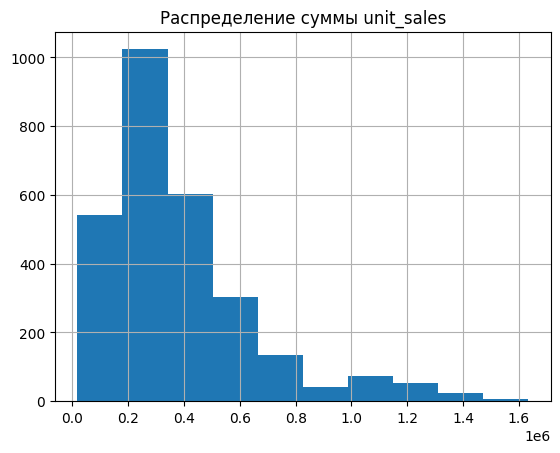

In [90]:
plt.title('Распределение суммы unit_sales')
df_w_first_act_month.sum_unit_sales.hist()

<Axes: title={'center': 'Распределение логарифма суммы unit_sales'}>

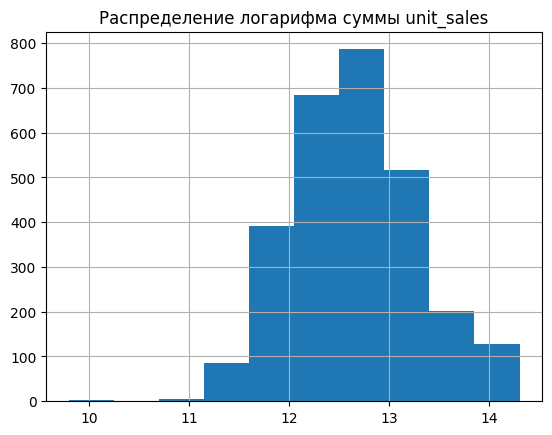

In [92]:
plt.title('Распределение логарифма суммы unit_sales')
np.log(df_w_first_act_month.sum_unit_sales).hist()

In [93]:
merged_df.head()

,store_nbr,month_dt,sum_unit_sales,first_act_month,last_act_month,zero_sales_flg
0,1,2013-01-01,156864.199,2013-01-01,2017-08-01,0
1,1,2013-02-01,129814.332,2013-01-01,2017-08-01,0
2,1,2013-03-01,151666.228,2013-01-01,2017-08-01,0
3,1,2013-04-01,155848.494,2013-01-01,2017-08-01,0
4,1,2013-05-01,154965.652,2013-01-01,2017-08-01,0


In [97]:
def date_to_num_month_s(d):
    return(d.dt.year * 12 + d.dt.month)

modelling_dataset = merged_df[['store_nbr','month_dt','zero_sales_flg','sum_unit_sales','first_act_month']]

modelling_dataset['mob'] = date_to_num_month_s(modelling_dataset['month_dt']) \
        - date_to_num_month_s(modelling_dataset['first_act_month'])

modelling_dataset['to_predict_flg'] = modelling_dataset.mob.apply(lambda x: 1 if x > 10 else 0)

modelling_dataset['mobs_to_predict_list'] = modelling_dataset.mob.apply(lambda x: [x+1,x+2,x+3])

for ix in tqdm(modelling_dataset.index):
    
    store_nbr = modelling_dataset.at[ix, 'store_nbr']
    mob = modelling_dataset.at[ix, 'mob']
    mobs_list = modelling_dataset.at[ix, 'mobs_to_predict_list']

    target = 0
    counter = 0

    for mob_ in mobs_list:
        try:
            target += modelling_dataset[
                (modelling_dataset.store_nbr == store_nbr) 
                & (modelling_dataset.mob == mob_)
                ]['sum_unit_sales'].iloc[0]
            counter += 1
        except:
            continue
    if counter == 3:
        modelling_dataset.at[ix, 'target'] = target
    else:
        continue

100%|██████████████████████████████████████| 2808/2808 [00:03<00:00, 899.40it/s]


In [98]:
modelling_dataset.head()

,store_nbr,month_dt,zero_sales_flg,sum_unit_sales,first_act_month,mob,to_predict_flg,mobs_to_predict_list,target
0,1,2013-01-01,0,156864.199,2013-01-01,0.0,0,"[1.0, 2.0, 3.0]",437329.054
1,1,2013-02-01,0,129814.332,2013-01-01,1.0,0,"[2.0, 3.0, 4.0]",462480.374
2,1,2013-03-01,0,151666.228,2013-01-01,2.0,0,"[3.0, 4.0, 5.0]",464865.573
3,1,2013-04-01,0,155848.494,2013-01-01,3.0,0,"[4.0, 5.0, 6.0]",465774.297
4,1,2013-05-01,0,154965.652,2013-01-01,4.0,0,"[5.0, 6.0, 7.0]",459991.958


In [99]:
modelling_dataset.to_csv('./df_to_predict_w_target.csv', index=False)